In [1]:
# Marketing Funnel & Conversion Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)

n = 500

data = pd.DataFrame({
    'User_ID': range(1, n + 1),
    'Lead_Source': np.random.choice(['Organic', 'Paid Ads', 'Referral', 'Social Media'], n),
    'Visits': np.random.randint(1, 10, n),
    'Pages_Viewed': np.random.randint(1, 20, n),
    'Time_Spent_Minutes': np.random.randint(1, 60, n),
    'Converted': np.random.choice([0, 1], n, p=[0.7, 0.3])
})

data.head()

,User_ID,Lead_Source,Visits,Pages_Viewed,Time_Spent_Minutes,Converted
0,1,Referral,5,6,25,0
1,2,Social Media,7,18,34,0
2,3,Organic,1,10,12,1
3,4,Referral,3,5,42,0
4,5,Referral,2,10,9,0


In [4]:
conversion_rate = data['Converted'].mean() * 100
print(f"Conversion Rate: {conversion_rate:.2f}%")

Conversion Rate: 29.20%


In [5]:
conversion_by_source = data.groupby('Lead_Source')['Converted'].mean() * 100
conversion_by_source

,Converted
Lead_Source,
Organic,32.786885
Paid Ads,29.629630
Referral,25.409836
Social Media,29.054054


In [6]:
total_users = len(data)
visited = data['Visits'].gt(0).sum()
engaged = data['Pages_Viewed'].gt(5).sum()
converted = data['Converted'].sum()

funnel = pd.Series({
    'Total Users': total_users,
    'Visited': visited,
    'Engaged': engaged,
    'Converted': converted
})

funnel

,0
Total Users,500
Visited,500
Engaged,360
Converted,146


In [7]:
drop_off = funnel.pct_change() * -100
drop_off

,0
Total Users,NaN
Visited,-0.000000
Engaged,28.000000
Converted,59.444444


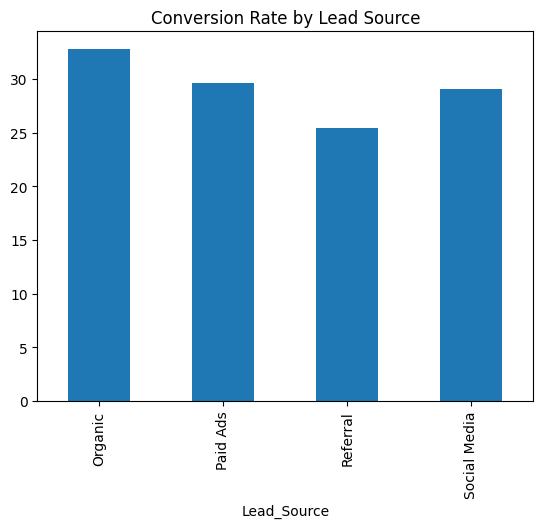

In [8]:
conversion_by_source.plot(kind='bar', title='Conversion Rate by Lead Source')
plt.show()

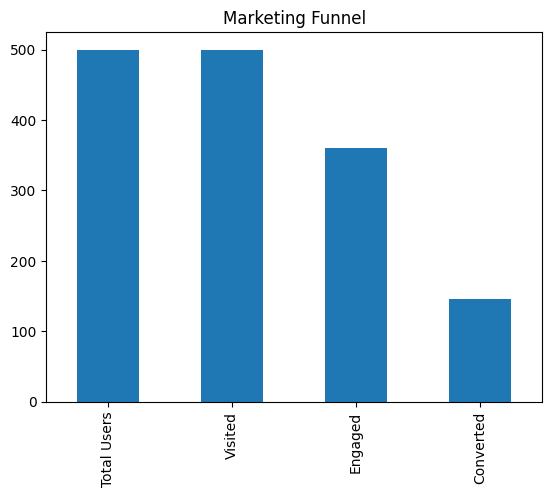

In [9]:
funnel.plot(kind='bar', title='Marketing Funnel')
plt.show()